### 🆛 Downloading 3D Building Data
This section involves the download process of 3D BAG (Basisregistratie Adressen en Gebouwen) data through a Web Feature Service (WFS) API call. The script constructs a URL with necessary parameters to fetch detailed 3D building data within a specified bounding box. The data is processed in batches and saved into a CSV file for analysis.</br></br>

**Why?**
The 3D data provides critical details on building heights and number of floors, which are essential for classifying the buildings.

In [1]:
import urllib.request
import urllib.parse
import json
import csv
import time

bbox = "5.02519,52.03450,5.19433,52.15479,EPSG:4326"
base_url = "https://data.3dbag.nl/api/BAG3D/wfs?"
params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typenames": "BAG3D:lod12",
    "bbox": bbox,
    "propertyName": "identificatie,b3_bouwlagen,b3_h_maaiveld,b3_h_nok",
    "outputFormat": "application/json",
    "count": "1000"
}

start = 0
batch_size = 1000
total_downloaded = 0

print("Start downloading: identificatie, b3_bouwlagen, b3_h_maaiveld, b3_h_nok from 3D-BAG API\n")

with open(r"intermediate_results\3d_bag_data.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["identificatie", "b3_bouwlagen", "b3_h_maaiveld", "b3_h_nok"])

    while True:
        params["startIndex"] = str(start)
        url = base_url + urllib.parse.urlencode(params)
        print(f"Requesting batch starting at {start:,}")

        try:
            with urllib.request.urlopen(url) as response:
                data = json.load(response)
        except Exception as e:
            print("Error fetching batch:", e)
            break

        features = data.get("features", [])
        if not features:
            print("No more features found.")
            break

        for feat in features:
            props = feat["properties"]
            writer.writerow([
                props.get("identificatie"),
                props.get("b3_bouwlagen"),
                props.get("b3_h_maaiveld"),
                props.get("b3_h_nok")
            ])

        total_downloaded += len(features)
        print(f"  Retrieved {len(features)} features (total {total_downloaded:,})")

        start += batch_size

        # Pause to avoid overloading the server
        time.sleep(0.2)

print("All results have been saved to: intermediate results/3d_bag_data.csv")

Start downloading: identificatie, b3_bouwlagen, b3_h_maaiveld, b3_h_nok from 3D-BAG API

Requesting batch starting at 0
  Retrieved 1000 features (total 1,000)
Requesting batch starting at 1,000
  Retrieved 1000 features (total 2,000)
Requesting batch starting at 2,000
  Retrieved 1000 features (total 3,000)
Requesting batch starting at 3,000
  Retrieved 1000 features (total 4,000)
Requesting batch starting at 4,000
  Retrieved 1000 features (total 5,000)
Requesting batch starting at 5,000
  Retrieved 1000 features (total 6,000)
Requesting batch starting at 6,000
  Retrieved 1000 features (total 7,000)
Requesting batch starting at 7,000
  Retrieved 1000 features (total 8,000)
Requesting batch starting at 8,000
  Retrieved 1000 features (total 9,000)
Requesting batch starting at 9,000
  Retrieved 1000 features (total 10,000)
Requesting batch starting at 10,000
  Retrieved 1000 features (total 11,000)
Requesting batch starting at 11,000
  Retrieved 1000 features (total 12,000)
Requesting

---
### 🛢 Load from BAG all the buildings with function: 🏠 residential
In this segment, we extract and process building data from the BAG dataset, focusing on first residential buildings. The process includes reading specific layers, filtering for only residential (woonfunctie) buildings, and writing the data into a GeoPackage file while maintaining essential attributes related to building function and address counts.</br></br>
**Why?** Focusing on residential buildings allows for classification to the types <code>single house</code>, <code>row house</code>, <code>apartment</code> and <code>highrise</code>

In [2]:
import os
import geopandas as gpd
from shapely.geometry import box

# Define the bounding box for Utrecht
bbox_4326 = box(5.02519, 52.03450, 5.19433, 52.15479)
bbox_28992_gdf = gpd.GeoDataFrame(geometry=[bbox_4326], crs=4326).to_crs(28992)
bbox_28992 = tuple(bbox_28992_gdf.total_bounds)

print("Bounding box set to: ",bbox_28992)

# Read the 'pand' layer, filter and rename columns
bag_gdf = gpd.read_file(
    r'D:\gis_files\vector\bag\20251028_bag-light.gpkg', # Local copy of BAG-light
    columns=['identificatie', 'status', 'gebruiksdoel', 'aantal_verblijfsobjecten', 'geometry'],
    layer='pand',
    bbox=bbox_28992
)

bag_gdf = bag_gdf.rename(columns={
    'identificatie': 'id',
    'gebruiksdoel': 'function',
    'aantal_verblijfsobjecten': 'n_addresses'
})

# Filter out records with 0 addresses and non-residential functions
bag_gdf = bag_gdf[bag_gdf['n_addresses'] != 0]

# r for residential
r_bag_gdf = bag_gdf[bag_gdf['function'] == 'woonfunctie']

# Read the 'verblijfsobject' layer, filter and rename columns
bag_address_gdf = gpd.read_file(
    r'D:\gis_files\vector\bag\20251028_bag-light.gpkg',
    columns=['identificatie', 'oppervlakte', 'gebruiksdoel', 'pand_identificatie'],
    layer='verblijfsobject',
    bbox=bbox_28992
)

bag_address_gdf = bag_address_gdf.rename(columns={
    'identificatie': 'id',
    'oppervlakte': 'floor_area',
    'gebruiksdoel': 'function',
    'pand_identificatie': 'property_id'
})

# Filter for residential use
r_bag_address_gdf = bag_address_gdf[bag_address_gdf['function'] == 'woonfunctie']

table_style = [
                {
                    'selector': 'th',
                    'props': [
                        ('background-color', '#2A4D69'),
                        ('color', 'white'),
                        ('padding', '6px'),
                        ('text-align', 'center')
                    ]
                },
                {
                    'selector': 'td',
                    'props': [
                        ('padding', '4px 8px')
                    ]
                }
            ]

print("\nLoaded BAG and filtered for residential entries only:")
display(r_bag_gdf.head(8)
                 .style
                 .set_table_styles(table_style)
                 )



Bounding box set to:  (np.float64(130159.042213703), np.float64(449591.6369520211), np.float64(141800.7568583695), np.float64(463019.2145997105))

Loaded BAG and filtered for residential entries only:


,n_addresses,function,id,status,geometry
2,1,woonfunctie,0312100000007909,Pand in gebruik,"POLYGON ((141421.101 452315.839, 141421.691 452307.358, 141434.873 452308.182, 141434.839 452308.864, 141447.093 452309.479, 141446.369 452317.322, 141437.77 452316.711, 141421.101 452315.839))"
10,1,woonfunctie,0312100000008056,Pand in gebruik,"POLYGON ((141379.524 452893.524, 141374.876 452892.808, 141374.854 452892.953, 141366.077 452891.605, 141367.847 452880.112, 141371.925 452880.738, 141371.075 452886.253, 141375.463 452886.929, 141375.535 452886.464, 141380.773 452887.272, 141379.803 452893.567, 141379.524 452893.524))"
11,1,woonfunctie,0312100000004309,Pand in gebruik,"POLYGON ((141285.687 452910.216, 141285.825 452910.238, 141292.354 452911.293, 141290.603 452922.592, 141293.166 452922.955, 141292.354 452928.698, 141291.754 452932.671, 141289.461 452932.384, 141287.863 452932.184, 141288.434 452928.169, 141288.873 452928.211, 141289.537 452923.057, 141290.165 452923.17, 141290.318 452922.129, 141284.119 452921.157, 141284.056 452921.147, 141283.974 452921.134, 141285.687 452910.216))"
12,1,woonfunctie,0312100000000353,Pand in gebruik,"POLYGON ((141297.384 452915.59, 141303.432 452916.493, 141303.83 452913.998, 141310.036 452914.946, 141308.377 452925.804, 141307.879 452929.592, 141295.302 452927.639, 141296.301 452921.1, 141296.595 452921.142, 141297.384 452915.59))"
13,1,woonfunctie,0312100000007844,Pand in gebruik,"POLYGON ((141310.036 452914.946, 141316.968 452916.005, 141315.337 452925.884, 141315.141 452925.855, 141314.867 452927.628, 141317.859 452928.15, 141316.847 452934.537, 141313.102 452933.943, 141314.126 452927.829, 141311.302 452927.37, 141311.445 452926.248, 141308.377 452925.804, 141310.036 452914.946))"
14,1,woonfunctie,0312100000004314,Pand in gebruik,"POLYGON ((141335.147 452918.964, 141333.53 452928.877, 141330.453 452928.393, 141330.3 452929.442, 141327.893 452929.126, 141325.901 452942.353, 141322.513 452941.859, 141324.341 452929.317, 141326.873 452929.639, 141328.628 452917.971, 141335.147 452918.964))"
15,1,woonfunctie,0312100000004315,Pand in gebruik,"POLYGON ((141335.147 452918.964, 141341.665 452920.004, 141339.787 452931.849, 141342.441 452932.256, 141341.648 452937.359, 141338.105 452936.88, 141338.644 452933.48, 141336.396 452933.126, 141337.001 452929.424, 141333.727 452928.908, 141333.53 452928.877, 141333.6 452928.445, 141335.147 452918.964))"
17,1,woonfunctie,0312100000007845,Pand in gebruik,"POLYGON ((141390.352 452933.518, 141389.507 452938.428, 141392.714 452938.978, 141389.317 452958.721, 141380.086 452957.138, 141384.327 452932.484, 141390.352 452933.518))"


---
### 🪢 Combine BAG and BAG3D to one gdf
This section details the merging of the 2D residential building data from BAG with the 3D geometric details from the BAG3D dataset. It involves renaming, cleaning identifiers, and calculating additional attributes such as building height derived from the difference between the rooftop (b3_h_nok) and ground level (b3_h_maaiveld) information.</br></br>

**Why?** Merging these datasets incorporates both BAG and BAG3d attributes of buildings, which is crucial for correctly classifying the buildings

In [3]:
import pandas as pd
import geopandas as gpd

bag3d_df = pd.read_csv(r'intermediate_results\3d_bag_data.csv')

# Rename columns for clarity
bag3d_df = bag3d_df.rename(columns={
    'identificatie': 'id',
    'b3_bouwlagen': 'n_floors'
})

# Clean the 'id' column by removing a specific prefix
bag3d_df["id"] = bag3d_df["id"].str.replace("NL.IMBAG.Pand.", "", regex=False)

# Merge the bag GeoDataFrame with the 3D data DataFrame on 'id'
r_bag_bag3d_gdf = r_bag_gdf.merge(bag3d_df, on='id', how='left')

# Calculate the building height based on rooftop and ground level heights
r_bag_bag3d_gdf['b3_h_pand'] = r_bag_bag3d_gdf['b3_h_nok'] - r_bag_bag3d_gdf['b3_h_maaiveld']

# Drop columns that are no longer needed
r_bag_bag3d_gdf = r_bag_bag3d_gdf.drop(columns=['status', 'b3_h_nok', 'b3_h_maaiveld'])
r_bag_bag3d_gdf['n_floors'] = r_bag_bag3d_gdf['n_floors'].fillna(-9999).astype(int)

print("BAG and BAG3d data have been combined, adding number of floors and height of the building")
display(r_bag_bag3d_gdf.drop(columns=['geometry'])
                       .head(8)
                       .style
                       .set_table_styles(table_style)
                       .format({'b3_h_pand': '{:.2f}'})
                       )

BAG and BAG3d data have been combined, adding number of floors and height of the building


,n_addresses,function,id,n_floors,b3_h_pand
0,1,woonfunctie,0312100000007909,2,7.18
1,1,woonfunctie,0312100000008056,2,8.73
2,1,woonfunctie,0312100000004309,3,9.89
3,1,woonfunctie,0312100000000353,3,9.55
4,1,woonfunctie,0312100000007844,3,9.82
5,1,woonfunctie,0312100000004314,3,10.16
6,1,woonfunctie,0312100000004315,3,9.78
7,1,woonfunctie,0312100000007845,2,7.01


---
### ☞ Calculate number of buildings each building touches
This part calculates how many buildings each building directly touches. It achieves this by employing spatial indexing techniques to calculate adjacency between building geometries.</br></br>

**Why?** Understanding building adjacency helps in classifying housing types. Especially in the case af <code>single house</code> and <code>row house</code>

In [4]:
import geopandas as gpd

# Create a spatial index
sindex = r_bag_bag3d_gdf.sindex

def count_touches(row, gdf=r_bag_bag3d_gdf, sindex=sindex):
    possible_matches_index = list(sindex.intersection(row.geometry.bounds))
    possible_matches = gdf.iloc[possible_matches_index]
    
    # Determine which possible matches actually touch the row's geometry
    touches_mask = possible_matches.geometry.touches(row.geometry)
    
    # Subtract one if the geometry touches itself, else sum all touches
    if row.name in possible_matches.index:
        count = touches_mask.sum() - touches_mask.iloc[possible_matches.index.get_loc(row.name)]
    else:
        count = touches_mask.sum()
    
    return count

r_bag_bag3d_gdf["touch_count"] = r_bag_bag3d_gdf.apply(count_touches, axis=1)
print("Added the number of buildings that each building touches:")
display(r_bag_bag3d_gdf.drop(columns=['geometry'])
                       .head(8)
                       .style
                       .set_table_styles(table_style)
                       .format({'b3_h_pand': '{:.2f}'})
                       )

Added the number of buildings that each building touches:


,n_addresses,function,id,n_floors,b3_h_pand,touch_count
0,1,woonfunctie,0312100000007909,2,7.18,0
1,1,woonfunctie,0312100000008056,2,8.73,0
2,1,woonfunctie,0312100000004309,3,9.89,1
3,1,woonfunctie,0312100000000353,3,9.55,1
4,1,woonfunctie,0312100000007844,3,9.82,1
5,1,woonfunctie,0312100000004314,3,10.16,0
6,1,woonfunctie,0312100000004315,3,9.78,0
7,1,woonfunctie,0312100000007845,2,7.01,0


---
### 🏠🏣 Rule-based classification of housing
Here, buildings are classified into categories like <code>single_house</code>, <code>row_house</code>, and <code>apartments</code> based on their spatial and attribute characteristics such as the number of addresses, adjacency to other buildings, and identified function. The class <code>potential_highrise</code> returns <font color=#57B9FF>True</font> of which we are not sure whether it is an apartment or highrise.</br></br>

**Why?** Classifying buildings into residential typologies assists in urban management, policy-making, and ensuring that each housing type is appropriately planned and serviced."

In [5]:
import geopandas as gpd

r_bag_bag3d_gdf['single_house'] = (
    (r_bag_bag3d_gdf['n_addresses'] == 1) &
    (r_bag_bag3d_gdf['function'] == 'woonfunctie') &
    (r_bag_bag3d_gdf['touch_count'] == 0)
)

r_bag_bag3d_gdf['twee_onder_een_kap'] = (
    (r_bag_bag3d_gdf['n_addresses'] == 2) &
    (r_bag_bag3d_gdf['function'] == 'woonfunctie') &
    (r_bag_bag3d_gdf['touch_count'] == 0)
)

r_bag_bag3d_gdf['row_house'] = (
    (r_bag_bag3d_gdf['n_addresses'] <= 2) &
    (r_bag_bag3d_gdf['function'] == 'woonfunctie') &
    (r_bag_bag3d_gdf['touch_count'] >= 1)
)

r_bag_bag3d_gdf['apartment'] = (
    (r_bag_bag3d_gdf['n_addresses'] >= 3) &
    (r_bag_bag3d_gdf['function'] == 'woonfunctie')
)

# Potential, because we are not sure if it is highrise yet
r_bag_bag3d_gdf['potential_highrise'] = (
    (r_bag_bag3d_gdf['n_addresses'] >= 6) &
    (r_bag_bag3d_gdf['function'] == 'woonfunctie') &
    (r_bag_bag3d_gdf['n_floors'] == -9999)
)

print("Added created a truth table to classify the residential buildings based on conditions:")
display(r_bag_bag3d_gdf[['id','single_house','twee_onder_een_kap', 'row_house', 'apartment', 'potential_highrise']].head(8)
                                                                                                                   .style
                                                                                                                   .set_table_styles(table_style)
                                                                                                                   .format({'b3_h_pand': '{:.2f}'})
                       )


Added created a truth table to classify the residential buildings based on conditions:


,id,single_house,twee_onder_een_kap,row_house,apartment,potential_highrise
0,0312100000007909,True,False,False,False,False
1,0312100000008056,True,False,False,False,False
2,0312100000004309,False,False,True,False,False
3,0312100000000353,False,False,True,False,False
4,0312100000007844,False,False,True,False,False
5,0312100000004314,True,False,False,False,False
6,0312100000004315,True,False,False,False,False
7,0312100000007845,True,False,False,False,False


---
### ⮺ Get cadastral parcel that the building is on, and clip to the built-up area of the parcel
This step involves obtaining cadastral parcel data for BAG polygons that are potentially high-rise buildings. Retrieved parcels also include non-built up areas like gardens, therefore they are then clipped to the extent of the BAG polygons to obtain precise built-up areas.</br></br>

**Why?** To see if a building is really a high-rise building we want to know the floor area of the building. The only problem is:</br></br>

In some cases, the addresses are based on the location of the front-door, and not the actual location of the dwelling. This can lead to a false ratio of floor area per bag-polygon and if we calculate material volumes at a later stage, the total material volume data will be skewed as well. Therefore we need to relate the BAG polygons that belong to the same building, and distribute the floor area accordingly: </br></br>

------------------------------BAG------------------------------------------------------Kadaster-----------------------------

![image](images/Melissakade-Utrecht_BAG.png)&nbsp;&nbsp;&nbsp;&nbsp;![image](images/Melissakade-Utrecht_Kadaster.png)</br>


Retreiving all parcels of potential highrise buildings...


Processing: 100%|██████████| 435/435 [07:18<00:00,  1.01s/it]


Clip full parcels to the buildings in the BAG

Legend:
🟥 Red polygons are the full parcels
🟩 Green polygons are the parts of the parcel with buildings


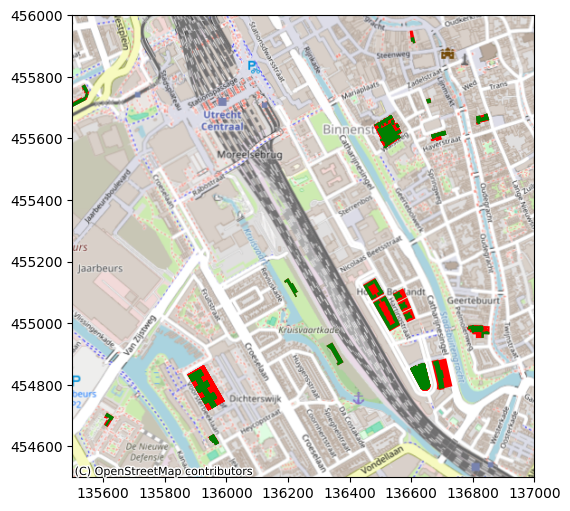

In [6]:
import geopandas as gpd
import requests
from io import BytesIO
from tqdm import tqdm
import matplotlib.pyplot as plt
import contextily as cx
import time
from urllib.parse import quote
import sys

# Filter the GeoDataFrame to include only high-rise apartments
highrise_gdf = r_bag_bag3d_gdf[
    r_bag_bag3d_gdf['potential_highrise'] == True
].copy()

# Calculate a representative center point for each geometry
highrise_gdf['centre_point'] = highrise_gdf['geometry'].apply(lambda geom: geom.representative_point())

# Convert the center points to integer coordinates
highrise_gdf['centre_point'] = highrise_gdf['centre_point'].apply(
    lambda coordinate: (int(coordinate.x), int(coordinate.y))
)

# Convert the series of center points to a list
centre_point_list = highrise_gdf['centre_point'].tolist()

temp_gdfs = []

# Iterate over the points with a progress bar
print("Retreiving all parcels of potential highrise buildings...")

if len(centre_point_list) == 0:
    print("\n No potential highrise buildings in bbox, skip this and next codeblock")
    sys.exit(0)

for x, y in tqdm(centre_point_list, desc="Processing"):
    # Define the filter XML for the WFS request
    filter_xml = f"""
    <Filter>
      <Intersects>
        <PropertyName>geom</PropertyName>
        <gml:Point srsName="EPSG:28992">
          <gml:coordinates>{x},{y}</gml:coordinates>
        </gml:Point>
      </Intersects>
    </Filter>
    """

    # Encode the filter for the request URL
    encoded_filter = quote(filter_xml)

    # Construct the WFS request URL
    url = (
        f"https://service.pdok.nl/kadaster/kadastralekaart/wfs/v5_0?"
        f"SERVICE=WFS&VERSION=2.0.0&REQUEST=GetFeature&TYPENAMES=kadastralekaart:Perceel&"
        f"SRSNAME=EPSG:28992&PROPERTYNAME=geom&FILTER={encoded_filter}"
    )

    # Send the request and read the response into a GeoDataFrame
    response = requests.get(url)
    response.raise_for_status()
    gdf = gpd.read_file(BytesIO(response.content))
    
    temp_gdfs.append(gdf)
    
    # Sleep to prevent overloading the server
    time.sleep(0.2)

# Combine the temporary GeoDataFrames into a single GeoDataFrame
highrise_parcel_gdf = gpd.GeoDataFrame(pd.concat(temp_gdfs, ignore_index=True))
highrise_parcel_gdf = highrise_parcel_gdf.rename(columns={'gml_id': 'parcel_id'})

# Clip parcels to within the BAG buildings
print("Clip full parcels to the buildings in the BAG")
highrise_parcel_clip_gdf = gpd.clip(highrise_parcel_gdf, r_bag_bag3d_gdf)

# Explode multipart geometries into single parts
highrise_parcel_clip_gdf = highrise_parcel_clip_gdf.explode(column='geometry').copy()

# Calculate the area of each parcel geometry and filter out small features
highrise_parcel_clip_gdf['parcel_area'] = highrise_parcel_clip_gdf['geometry'].area
highrise_parcel_clip_gdf = highrise_parcel_clip_gdf[highrise_parcel_clip_gdf['parcel_area'] > 10]

# Drop unnecessary columns
highrise_parcel_clip_gdf = highrise_parcel_clip_gdf.drop(columns=['lowerCorner', 'upperCorner'])

# Plot the results
fig, ax = plt.subplots(figsize=(6, 6))
print("\nLegend:\n🟥 Red polygons are the full parcels")
print("🟩 Green polygons are the parts of the parcel with buildings")
highrise_parcel_gdf.plot(ax=ax, color="red", linewidth=1)
highrise_parcel_clip_gdf.plot(ax=ax, color='green', linewidth=1)

# Set axis limits for example
ax.set_xlim(135500, 137000)
ax.set_ylim(454500, 456000)
cx.add_basemap(ax=ax, source=cx.providers.OpenStreetMap.Mapnik, zoom=15, crs='EPSG:28992')

plt.show()

---
### 👣 Discover building clusters and calculate their floor area to footprint ratio
In the real world, a building might have multiple BAG polygons assiciated with it. In this step, BAG polygons are clustered that are part of the same building.  </br></br>

**Why?** Combining the BAG polygons of the same building gives us a more realistic insight in the floor area of the building and its footprint on the ground. With this we can calculate the ratio and use it to determine the approximate number of floors and classification of the building.

In [7]:
import geopandas as gpd

# Prepare for spatial join
highrise_parcel_clip_gdf = highrise_parcel_clip_gdf.copy()
highrise_parcel_clip_gdf['geom_parcel'] = highrise_parcel_clip_gdf['geometry']

# Perform spatial join to associate BAG data with parcel data
bag_highrise_parcel_gdf = gpd.sjoin(
    r_bag_bag3d_gdf[['geometry','id','n_addresses']], 
    highrise_parcel_clip_gdf[['geometry', 'parcel_id', 'geom_parcel']], 
    how='inner', 
    predicate='intersects'
)

# Compute overlap area between buildings and parcels
bag_highrise_parcel_gdf = bag_highrise_parcel_gdf.copy()
bag_highrise_parcel_gdf['intersection_area'] = bag_highrise_parcel_gdf.geometry.intersection(
    bag_highrise_parcel_gdf['geom_parcel']
).area

# Compute overlap ratio
bag_highrise_parcel_gdf['overlap_ratio'] = (
    bag_highrise_parcel_gdf['intersection_area'] / bag_highrise_parcel_gdf['geometry'].area
)

# Remove duplicates, keeping the one with the largest overlap ratio
bag_highrise_parcel_gdf = bag_highrise_parcel_gdf.sort_values('overlap_ratio', ascending=False).drop_duplicates(subset='id')

# Dissolve parcels into clusters and explode multipart geometries
bag_cluster_gdf = bag_highrise_parcel_gdf.dissolve().explode()

bag_cluster_gdf['cluster_id'] = range(len(bag_cluster_gdf))
bag_cluster_gdf = bag_cluster_gdf[['geometry', 'cluster_id']].copy()

# Drop unnecessary columns
bag_highrise_parcel_gdf = bag_highrise_parcel_gdf.drop(columns=['index_right','overlap_ratio','intersection_area'])

# Join the cluster IDs back onto the original GeoDataFrame
bag_highrise_parcel_gdf = gpd.sjoin(
    bag_highrise_parcel_gdf,
    bag_cluster_gdf,
    how='left',
    predicate='intersects'
)

# Aggregate floor area by property ID
r_bag_address_gdf['floor_area_property'] = r_bag_address_gdf.groupby('property_id')['floor_area'].transform('sum')
r_bag_address_gdf = r_bag_address_gdf.drop_duplicates(subset=['property_id'], keep='first')

# Merge the address data into the main GeoDataFrame
bag_highrise_parcel_gdf = bag_highrise_parcel_gdf.merge(
    r_bag_address_gdf[['property_id', 'floor_area_property']], 
    left_on='id', 
    right_on='property_id', 
    how='left'
)

# Check if the same building has the same parcel and cluster ID
bag_highrise_parcel_gdf['same_building'] = bag_highrise_parcel_gdf.duplicated(subset=['parcel_id', 'cluster_id'], keep=False)
bag_highrise_parcel_gdf['building_area'] = bag_highrise_parcel_gdf['geometry'].area.astype(int)

# Summarize data for each cluster
bag_highrise_parcel_gdf['cluster_addresses'] = bag_highrise_parcel_gdf.loc[bag_highrise_parcel_gdf['same_building'], :].groupby('cluster_id')['n_addresses'].transform('sum')
bag_highrise_parcel_gdf['cluster_addresses'] = bag_highrise_parcel_gdf['cluster_addresses'].fillna(bag_highrise_parcel_gdf['n_addresses']).astype(int)

bag_highrise_parcel_gdf['cluster_building_area'] = bag_highrise_parcel_gdf.loc[bag_highrise_parcel_gdf['same_building'], :].groupby('cluster_id')['building_area'].transform('sum')
bag_highrise_parcel_gdf['cluster_building_area'] = bag_highrise_parcel_gdf['cluster_building_area'].fillna(bag_highrise_parcel_gdf['building_area']).astype(int)

bag_highrise_parcel_gdf['cluster_floor_area'] = bag_highrise_parcel_gdf.loc[bag_highrise_parcel_gdf['same_building'], :].groupby('cluster_id')['floor_area_property'].transform('sum')
bag_highrise_parcel_gdf['cluster_floor_area'] = bag_highrise_parcel_gdf['cluster_floor_area'].fillna(bag_highrise_parcel_gdf['floor_area_property']).astype(int)

bag_highrise_parcel_gdf['corrected_floor_area'] = bag_highrise_parcel_gdf['building_area'] / bag_highrise_parcel_gdf['cluster_building_area'] * bag_highrise_parcel_gdf['cluster_floor_area']

# Calculate the ratio of floor area to building area
bag_highrise_parcel_gdf['floor_building_ratio'] = bag_highrise_parcel_gdf['cluster_floor_area'] / bag_highrise_parcel_gdf['cluster_building_area']

print("Clustering related buildings done")
print("Calculating floor area ratio done\n\n" \
      "• floor_area_property: the total floor area of all the addressess in the BAG building\n" \
      "• building_area: footprint of the BAG buidling on the ground\n" \
      "• cluster_addresses: total number of addressess in the cluster\n" \
      "• cluster_floor_area: total floor area of the cluster\n" \
      "• corrected floor area: estimated floor area of the BAG building based on the building area and the total floor area of the cluster\n" \
      "• floor_building_ratio: ratio of the cluster floor area tot the cluster building area")
display(bag_highrise_parcel_gdf.drop(columns=['geometry','geom_parcel','parcel_id','same_building','property_id','index_right'])
                       .head(8)
                       .style
                       .set_table_styles(table_style)
                       .format({'b3_h_pand': '{:.2f}','corrected_floor_area': '{:.2f}', 'floor_building_ratio': '{:.2f}'})
                       )

Clustering related buildings done
Calculating floor area ratio done

• floor_area_property: the total floor area of all the addressess in the BAG building
• building_area: footprint of the BAG buidling on the ground
• cluster_addresses: total number of addressess in the cluster
• cluster_floor_area: total floor area of the cluster
• corrected floor area: estimated floor area of the BAG building based on the building area and the total floor area of the cluster
• floor_building_ratio: ratio of the cluster floor area tot the cluster building area


C:\Users\gido.stoop\AppData\Roaming\Python\Python313\site-packages\geopandas\geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,id,n_addresses,cluster_id,floor_area_property,building_area,cluster_addresses,cluster_building_area,cluster_floor_area,corrected_floor_area,floor_building_ratio
0,0356100000071048,59,168,3420,977,59,977,3420,3420.00,3.50
1,0344100000032609,183,315,6022,1139,183,1139,6022,6022.00,5.29
2,0344100000016415,29,259,2211,279,264,2567,19679,2138.86,7.67
3,0344100000068305,58,104,5909,2476,58,2476,5909,5909.00,2.39
4,0344100000156982,42,102,2734,796,52,1436,4319,2394.10,3.01
5,0344100000018565,22,327,1984,234,56,958,5127,1252.32,5.35
6,0344100000026935,29,259,2211,278,264,2567,19679,2131.19,7.67
7,0344100000159674,1,101,160,69,13,687,1578,158.49,2.30


---
### Classify residential buildings
Now that we can also distingish apartments from highrise, it is time to classify the residential buildings.</br></br>

Unfortunately, some buildings will still be wrongly classified since the seperate buildings are not distinguishable via either BAG or Cadastral parcels. The best we can do is check the outliers manually afterwards.</br></br>

**Example:** This building is very hard to classify using the BAG and the cadastral parcels, as they are both quite awkwardly registered: </br></br>
------------------------------BAG-----------------------------------------------------Kadaster-----------------------------</br></br>
![image](images/Scharleistraat-Utrecht_BAG.png)&nbsp;&nbsp;&nbsp;&nbsp;![image](images/Scharleistraat-Utrecht_Kadaster.png)

In [8]:
import geopandas as gpd

# If the floor area is more than five times the footprint, classify as highrise
bag_highrise_parcel_gdf['highrise'] = (
    bag_highrise_parcel_gdf['floor_building_ratio'] > 5
)

r_bag_bag3d_complete_gdf = r_bag_bag3d_gdf.merge(
    bag_highrise_parcel_gdf[['id', 'highrise', 'corrected_floor_area']], 
    left_on='id', 
    right_on='id', 
    how='left'
)

r_bag_bag3d_complete_gdf['highrise'] = r_bag_bag3d_complete_gdf['highrise'].fillna(0).astype('bool')

def assign_class(row):
    if row['single_house'] == True:
        return 'single_house'
    elif row['row_house'] == True:
        return 'row_house'
    elif row['twee_onder_een_kap'] == True:
        return 'twee_onder_een_kap'
    elif row['highrise'] == True:
        return 'highrise'
    elif row['apartment'] == True:
        return 'apartment'

r_bag_bag3d_complete_gdf['classified'] = r_bag_bag3d_complete_gdf.apply(lambda x: assign_class(x), axis=1)

print('Classified every residential building to the categories: single house, row house, twee-onder-een-kap, apartment, highrise:')
display(r_bag_bag3d_complete_gdf[['id', 'classified']]
                       .head(8)
                       .style
                       .set_table_styles(table_style)
                       )

Classified every residential building to the categories: single house, row house, twee-onder-een-kap, apartment, highrise:


,id,classified
0,0312100000007909,single_house
1,0312100000008056,single_house
2,0312100000004309,row_house
3,0312100000000353,row_house
4,0312100000007844,row_house
5,0312100000004314,single_house
6,0312100000004315,single_house
7,0312100000007845,single_house


---
### 🔙 Merge back results and finalize classification
All residential buildings were filtered from the BAG. Now that they are classified, it is time to merge them back into the original dataset.</br></br>

**Why?** Once the residential buildings are merged, we are ready to classify all other buildings.

In [9]:
import os
import geopandas as gpd

# c for classified
c_bag_gdf = bag_gdf.merge(
    r_bag_bag3d_complete_gdf[['id', 'classified','corrected_floor_area']], 
    left_on='id', 
    right_on='id', 
    how='left'
)

def assign_class(row):
    if pd.isna(row['classified']) == False:
        return row['classified']
    else:
        if 'winkelfunctie' in row['function']:
            return 'commercial'
        elif 'kantoorfunctie' in row['function']:
            return 'office'
        else:
            return 'other'

# Filter out buildings without any addresses associated to it
c_bag_gdf['classified'] = c_bag_gdf.apply(lambda x: assign_class(x), axis=1)

print('Classified every building to the categories: single house, row house, twee-onder-een-kap, apartment, highrise, office, commercial and other:')
display(c_bag_gdf.drop(columns=['geometry', 'n_addresses', 'corrected_floor_area'])
                 .head(8)
                 .style
                 .set_table_styles(table_style)
                 )

Classified every building to the categories: single house, row house, twee-onder-een-kap, apartment, highrise, office, commercial and other:


,function,id,status,classified
0,woonfunctie,0312100000007909,Pand in gebruik,single_house
1,"industriefunctie,woonfunctie",0312100000007816,Pand in gebruik,other
2,bijeenkomstfunctie,0312100000001805,Pand in gebruik,other
3,overige gebruiksfunctie,0312100000010729,Pand in gebruik,other
4,"industriefunctie,woonfunctie",0312100000008055,Pand in gebruik,other
5,kantoorfunctie,0312100000008024,Pand in gebruik,office
6,woonfunctie,0312100000008056,Pand in gebruik,single_house
7,woonfunctie,0312100000004309,Pand in gebruik,row_house


---
### 🖩 Calculate material volumes based on category and floor area

Now that all the buildings are classified and the floor area is calculated, we can use the database of Sprecher et al. (2022) to calculate the approximate material volumes of the buildings in the current building stock.</br></br>

**Why?** With the approximate material volume of the current building stock, an approximation can be made of the material flows during building and demolition projects in the past and near future. 

###### Sprecher, B., Verhagen, T. J., Sauer, M. L., Baars, M., Heintz, J., & Fishman, T. (2022). Material intensity database for the Dutch building stock: Towards Big Data in material stock analysis. Journal of Industrial Ecology, 26(1), 272-280.

In [10]:
bag_address_gdf['floor_area_property'] = bag_address_gdf.groupby('property_id')['floor_area'].transform('sum')
bag_address_dropped_gdf = bag_address_gdf.drop_duplicates(subset=['property_id'], keep='first')

# Merge the address data into the main GeoDataFrame
# cc for classified and corrected
cc_bag_gdf = c_bag_gdf.merge(
    bag_address_dropped_gdf[['property_id', 'floor_area_property']], 
    left_on='id', 
    right_on='property_id', 
    how='left'
)

cc_bag_gdf['floor_area_property'] = cc_bag_gdf.apply(lambda x: x['floor_area_property'] if pd.isna(x['corrected_floor_area']) else x['corrected_floor_area'], axis=1)

material_volumes_df = pd.read_csv('sources/material_volumes.csv')

def calculate_volumes(row, material):
    if row['classified'] == 'single_house':
        return row['floor_area_property'] * material_volumes_df[material].iloc[0] # single
    elif row['classified'] == 'row_house' or row['classified'] == 'twee_onder_een_kap':
        return row['floor_area_property'] * material_volumes_df[material].iloc[1] # row
    elif row['classified'] == 'apartment':
        return row['floor_area_property'] * material_volumes_df[material].iloc[2] # appartment
    elif row['classified'] == 'highrise':
        return row['floor_area_property'] * material_volumes_df[material].iloc[3] # high_rise
    elif row['classified'] == 'office':
        return row['floor_area_property'] * material_volumes_df[material].iloc[5] # office, iloc[4] = residential total
    elif row['classified'] == 'other':
        return row['floor_area_property'] * material_volumes_df[material].iloc[6] # other
    elif row['classified'] == 'commercial':
        return row['floor_area_property'] * material_volumes_df[material].iloc[7] # commercial
    
materials = ['Bitumen (PVC, EPDM)','Roof gravel','Ceramics','Brickwork','Concrete','Steel','Gypsum','Glass wool','Glass','Wood','C&DW']

for material in materials:
    cc_bag_gdf[material] = cc_bag_gdf.apply(lambda x: calculate_volumes(x, material), axis=1).fillna(-9999).astype(int)

cc_bag_gdf['total_volume'] = cc_bag_gdf[materials].sum(axis=1)

print("Calculated the tonnage of each material in a BAG building based on the floor area and classification:")
display(cc_bag_gdf[['id', 'classified', 'Bitumen (PVC, EPDM)','Roof gravel','Ceramics','Brickwork','Concrete','Steel','Gypsum','Glass wool','Glass','Wood','C&DW']]
                 .head(8)
                 .style
                 .set_table_styles(table_style)
                 )



Calculated the tonnage of each material in a BAG building based on the floor area and classification:


,id,classified,"Bitumen (PVC, EPDM)",Roof gravel,Ceramics,Brickwork,Concrete,Steel,Gypsum,Glass wool,Glass,Wood,C&DW
0,0312100000007909,single_house,2093,0,3286,25316,72052,2521,1560,0,0,7964,7386
1,0312100000007816,other,3192,14539,2744,46612,82956,3009,1899,0,1051,5084,3810
2,0312100000001805,other,18375,83677,15794,268258,477423,17317,10930,0,6048,29263,21928
3,0312100000010729,other,325,1483,280,4756,8464,307,193,0,107,518,388
4,0312100000008055,other,2172,9891,1867,31708,56433,2047,1292,0,715,3459,2592
5,0312100000008024,office,10131,45521,0,320410,542114,19663,10580,5761,10554,19276,47988
6,0312100000008056,single_house,1292,0,2029,15636,44503,1557,963,0,0,4919,4562
7,0312100000004309,row_house,0,0,0,113081,173393,6068,0,0,0,38531,14450


---
### 💾 Save to file


Saved to file:  intermediate_results\bag_Utrecht_volumes_28992.gpkg


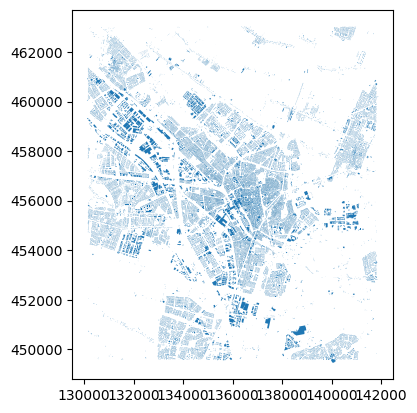

In [ ]:
import os
import matplotlib.pyplot as plt

output_file = r'output\bag_Utrecht_volumes_28992.gpkg'

# Remove existing file if it exists
if os.path.exists(output_file):
    os.remove(output_file)

#Export to a GeoPackage
cc_bag_gdf.to_file(output_file, driver='GPKG', layer='building_volumes')

cc_bag_gdf.plot()

print("Saved to file: ", output_file)

---
## 🗺 Some results
![image](images/Utrecht_building_classification.png)</br></br>
![image](images/Material_volumes_UNoord.png)